# Goal:

The goal of this document is to see how a decison tree, and random forest and logistic regression compare

In [65]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
#Loading in EPL 2023/24 match results
path = r"C:\Users\jahg9\OneDrive\Documents\Data Analysis Projects\EPL Match Prediction\epl_merged.csv"
epl_merged = pd.read_csv(path)

In [67]:
epl_merged['win'].unique()

array([1, 0])

In [68]:
print(epl_merged.columns.tolist())

['Date', 'Time', 'Comp', 'Round', 'Day', 'Venue', 'Result', 'GF', 'GA', 'Opponent_x', 'xG', 'xGA', 'Poss', 'Attendance', 'Captain', 'Formation', 'Referee', 'Match Report', 'Sh', 'SoT', 'Dist', 'FK', 'PK', 'PKatt', 'Season', 'Team', 'GD', 'xGD', 'win', 'Opponent_y', 'Opp_Sh', 'Opp_SoT', 'shot_diff', 'sot_diff', 'rolling_GF', 'rolling_GA', 'rolling_GD', 'rolling_xG', 'rolling_xGA', 'rolling_xGD', 'rolling_SoT', 'rolling_Sh', 'rolling_Poss']


# Data Setup and Preparation

In [69]:
#Define features
features = [
    'rolling_xGD',
    'rolling_GD', 
    'rolling_SoT',
    'rolling_Sh',
    'rolling_Poss'
]

#Clone dataframe to protect original
df = epl_merged.copy()

# Drop NaN rows from data
df = df.dropna(subset=features)

#Define x and y variables
X = df[features]
y = df['win']



In [70]:
#Import Scikit learn
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [71]:
#finding the total win rate within the dataset
print(epl_merged['win'].sum() / epl_merged['win'].count())
print(epl_merged['win'].mean())

0.39210526315789473
0.39210526315789473


In [72]:
# Import statsmodels formula API for logistic regression with summary output
import statsmodels.formula.api as smf

# Reconstruct training dataframe by combining features and target
train_df = X_train.copy()
train_df['win'] = y_train

# Dynamically build formula string from features list
formula = 'win ~ ' + ' + '.join(features)

# Fit logistic regression model on training data
log_model = smf.logit(formula, data=train_df).fit()

# Display model summary with coefficients, p-values, and confidence intervals
log_model.summary()

Optimization terminated successfully.
         Current function value: 0.628951
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                    win   No. Observations:                  528
Model:                          Logit   Df Residuals:                      522
Method:                           MLE   Df Model:                            5
Date:                Tue, 12 May 2026   Pseudo R-squ.:                 0.05465
Time:                        12:23:57   Log-Likelihood:                -332.09
converged:                       True   LL-Null:                       -351.28
Covariance Type:            nonrobust   LLR p-value:                 3.141e-07
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -3.0336      0.712     -4.262      0.000      -4.429      -1.639
rolling_xGD      0.1204      0.234      0.515      0.607      -0.338       0.579
rolling_GD      -0.0296      0.154     -0.192      0.848      -0.332       0.273
rolling_SoT      0.2354      0.131      1.803      0.071      -0.021       0.491
rolling_Sh      -0.0213      0.055     -0.387      0.699      -0.130       0.087
rolling_Poss     0.0346      0.013      2.636      0.008       0.009       0.060
================================================================================
"""

# I tried dropping rolling_GD to see if rolling_xGD would become significant (due to multicollinearity) and it did not. Neither variable appears to be significant

In [73]:
from sklearn.metrics import roc_auc_score, accuracy_score

# Get predictions on test set
y_pred_prob = log_model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

log_auc = roc_auc_score(y_test, y_pred_prob)
log_acc = accuracy_score(y_test, y_pred)

# AUC and accuracy
print('AUC:', roc_auc_score(y_test, y_pred_prob))
print('Accuracy:', accuracy_score(y_test, y_pred))

AUC: 0.6710526315789473
Accuracy: 0.6136363636363636


# The logistic achieved an AUC of 67% meaning it assigned a higher probability of winning to wins rather than non-wins 67% of the time

In [74]:
np.exp(log_model.params)

Intercept       0.048141
rolling_xGD     1.127953
rolling_GD      0.970807
rolling_SoT     1.265443
rolling_Sh      0.978878
rolling_Poss    1.035248
dtype: float64

# Each additional percentage point of average possession over the last 5 matches increases the odds of winning by about 3.5%.

# Decision Tree

In [75]:
# Import decision tree classifier and evaluation metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Instantiate and fit decision tree on training data
tree_model = DecisionTreeClassifier(random_state=42, max_depth=3)
tree_model.fit(X_train, y_train)

# Generate predictions on test set
y_pred_tree = tree_model.predict(X_test)

# Print precision, recall, f1-score per class
print(classification_report(y_test, y_pred_tree))

# Print confusion matrix
print(confusion_matrix(y_test, y_pred_tree))


              precision    recall  f1-score   support

           0       0.64      0.83      0.72        76
           1       0.61      0.36      0.45        56

    accuracy                           0.63       132
   macro avg       0.62      0.59      0.58       132
weighted avg       0.62      0.63      0.61       132

[[63 13]
 [36 20]]


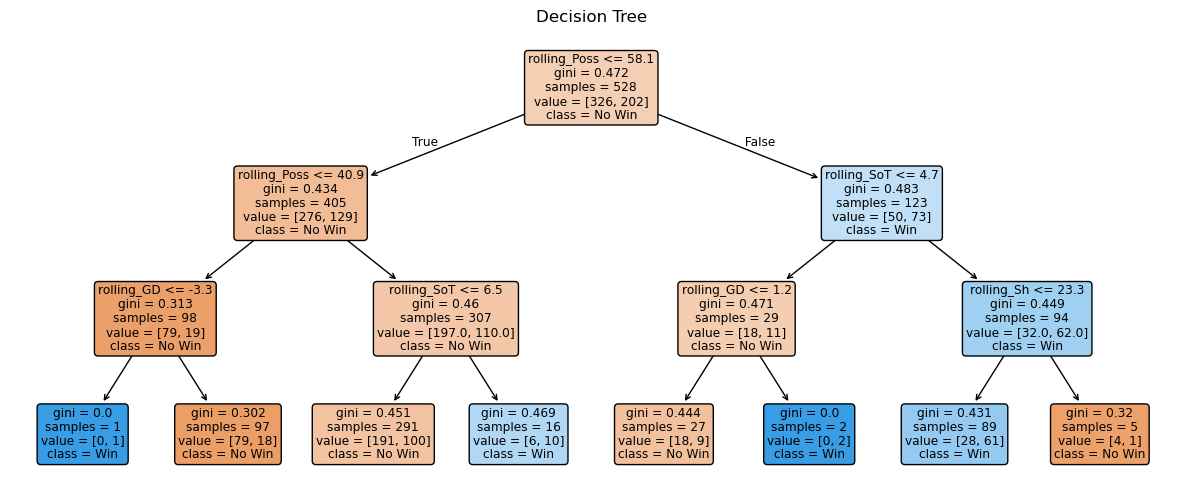

In [76]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot decision tree
plt.figure(figsize=(15, 6))
plot_tree(
    tree_model,
    feature_names=features,
    class_names=['No Win', 'Win'],
    filled=True,
    rounded=True
)
plt.title('Decision Tree')
plt.show()

In [77]:
from sklearn.metrics import roc_auc_score, accuracy_score

# Get predicted probabilities for AUC
y_pred_tree_prob = tree_model.predict_proba(X_test)[:, 1]


DT_auc = roc_auc_score(y_test, y_pred_tree_prob)
DT_acc = accuracy_score(y_test, y_pred_tree)

# Print AUC and accuracy
print('AUC:', roc_auc_score(y_test, y_pred_tree_prob))
print('Accuracy:', accuracy_score(y_test, y_pred_tree))

AUC: 0.6455592105263158
Accuracy: 0.6287878787878788


In [78]:
#Decision trees tend to shine when there are many features with complex interactions to discover. 
# With only 5 features, there isn't enough complexity for the tree's flexibility to be an advantage over logistic regression.

# This Decison Tree model achieved an AUC of 64% and an accuracy of 62%

# Running Tally

Logistic regression AUC: 67%


Decision tree AUC: 62%

# Random Forest

In [79]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,      # number of trees
    max_depth=3,           # prevent overfitting
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1              # use all CPU cores
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, min_samples_leaf=10, n_estimators=500,
                       n_jobs=-1, random_state=42)

In [80]:
#Generate Predictions
rf_pred = rf.predict(X_test)
rf_pred_prob = rf.predict_proba(X_test)[:,1]

In [81]:
#Generate Metrics
from sklearn.metrics import accuracy_score, roc_auc_score

rf_acc = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_pred_prob)

rf_accuracy, rf_auc

(0.6060606060606061, np.float64(0.6778665413533834))

# The random forest model achieve an auc of 67% and an accuracy of 60%

In [82]:
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importances.head(10)

rolling_Poss    0.335501
rolling_xGD     0.206183
rolling_Sh      0.194067
rolling_SoT     0.170735
rolling_GD      0.093514
dtype: float64

In [83]:
import pandas as pd

pd.DataFrame([
    ["Logistic Regression", log_auc, log_acc],
    ["Decision Tree", DT_auc, DT_acc],
    ["Random Forest", rf_auc, rf_accuracy]
], columns=["Model", "AUC", "Accuracy"])

,Model,AUC,Accuracy
0,Logistic Regression,0.671053,0.613636
1,Decision Tree,0.645559,0.628788
2,Random Forest,0.677867,0.606061


# Overall the three models are fairly close, which makes sense given there are 5 features and one season of data. The random forest edges out on AUC which is what matters most for a prediction task like this.